# This is my 14. global monthly electricity production project, where I achieved 96% Score using Random Forest.
# If you have any suggestions, please DM me.
# Even a small message from you can make a big impact on my career

# Import Required Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & splitting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# XGBoost
from xgboost import XGBRegressor

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Save the model
import joblib

# Load dataset

In [2]:
data = pd.read_csv("global_monthly_electricity_production_final.csv")
data.head()

,country,country_clean,region,is_developed,year,month,quarter,date,period,season,...,source_category,energy_type,electricity_production_gwh,share_of_total,is_renewable,is_fossil,energy_intensity_category,is_outlier,is_negative,is_zero
0,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,...,Fossil Fuel,Conventional,2747.782,0.020080,False,True,Medium,False,False,False
1,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,...,Renewable,Clean Energy,0.000,0.000000,True,False,Low,False,False,True
2,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,...,Renewable,Clean Energy,31843.542,0.232530,True,False,High,False,False,False
3,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,...,Fossil Fuel,Conventional,73921.692,0.536815,False,True,High,False,False,False
4,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,...,Other,Other,137590.832,1.000000,False,False,Very High,False,False,False


# Show hide columns

In [3]:
pd.options.display.max_columns = 23
data.head()

,country,country_clean,region,is_developed,year,month,quarter,date,period,season,year_category,energy_source,energy_source_clean,source_category,energy_type,electricity_production_gwh,share_of_total,is_renewable,is_fossil,energy_intensity_category,is_outlier,is_negative,is_zero
0,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,Early 2010s,Coal,Coal,Fossil Fuel,Conventional,2747.782,0.020080,False,True,Medium,False,False,False
1,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,Early 2010s,Geothermal,Geothermal,Renewable,Clean Energy,0.000,0.000000,True,False,Low,False,False,True
2,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,Early 2010s,Hydro,Hydro,Renewable,Clean Energy,31843.542,0.232530,True,False,High,False,False,False
3,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,Early 2010s,Natural gas,Natural Gas,Fossil Fuel,Conventional,73921.692,0.536815,False,True,High,False,False,False
4,Argentina,Argentina,South America,False,2015,1,1,2015-01-01,2010-2014,Winter,Early 2010s,Net electricity production,Net Electricity Production,Other,Other,137590.832,1.000000,False,False,Very High,False,False,False


# EDA

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4720 entries, 0 to 4719
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     4720 non-null   object 
 1   country_clean               4720 non-null   object 
 2   region                      3947 non-null   object 
 3   is_developed                4720 non-null   bool   
 4   year                        4720 non-null   int64  
 5   month                       4720 non-null   int64  
 6   quarter                     4720 non-null   int64  
 7   date                        4720 non-null   object 
 8   period                      4720 non-null   object 
 9   season                      4720 non-null   object 
 10  year_category               4720 non-null   object 
 11  energy_source               4720 non-null   object 
 12  energy_source_clean         4720 non-null   object 
 13  source_category             4720 

# Checking null values

In [5]:
data.isna().sum()

country                         0
country_clean                   0
region                        773
is_developed                    0
year                            0
month                           0
quarter                         0
date                            0
period                          0
season                          0
year_category                   0
energy_source                   0
energy_source_clean             0
source_category                 0
energy_type                     0
electricity_production_gwh      0
share_of_total                  0
is_renewable                    0
is_fossil                       0
energy_intensity_category       0
is_outlier                      0
is_negative                     0
is_zero                         0
dtype: int64

# Checking all columns unique values

In [6]:
data.nunique()

country                         52
country_clean                   52
region                           5
is_developed                     2
year                            13
month                            1
quarter                          1
date                            13
period                           3
season                           1
year_category                    3
energy_source                   10
energy_source_clean             10
source_category                  4
energy_type                      3
electricity_production_gwh    4278
share_of_total                3955
is_renewable                     2
is_fossil                        2
energy_intensity_category        4
is_outlier                       1
is_negative                      1
is_zero                          2
dtype: int64

# Select only object and bool columns

In [7]:
obj_bool_cols = data.select_dtypes(include=['object', 'bool']).columns

# Loop and print unique values

In [8]:
for col in obj_bool_cols:
    print(f"\nColumn: {col}")
    print(data[col].unique())


Column: country
['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'Chile' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Denmark' 'Estonia' 'Finland' 'France' 'Germany' 'Greece' 'Hungary'
 'IEA Total' 'Iceland' 'India' 'Ireland' 'Italy' 'Japan' 'Korea' 'Latvia'
 'Lithuania' 'Luxembourg' 'Malta' 'Mexico' 'Netherlands' 'New Zealand'
 'North Macedonia' 'Norway' 'OECD Americas' 'OECD Asia Oceania'
 'OECD Europe' 'OECD Total' 'Poland' 'Portugal' 'Republic of Turkiye'
 'Romania' 'Serbia' 'Slovak Republic' 'Slovenia' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']

Column: country_clean
['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'Chile' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Denmark' 'Estonia' 'Finland' 'France' 'Germany' 'Greece' 'Hungary'
 'IEA Total' 'Iceland' 'India' 'Ireland' 'Italy' 'Japan' 'Korea' 'Latvia'
 'Lithuania' 'Luxembourg' 'Malta' 'Mexico' 'Netherlands' 'New Zealan

# Drop duplicate or redundant columns

In [9]:
data.drop(columns=[
    "region",               # high null value this column
    "country",              # duplicate of country_clean
    "energy_source",        # duplicate of energy_source_clean
    "is_outlier",           # all False
    "is_negative"           # all False
], inplace=True)

# Standardize column naming

In [10]:
data.rename(columns={
    "country_clean": "country",
    "energy_source_clean": "energy_source"
}, inplace=True)

# Verify cleaned dataset

In [11]:
print("Remaining columns:\n", data.columns.tolist())

Remaining columns:
 ['country', 'is_developed', 'year', 'month', 'quarter', 'date', 'period', 'season', 'year_category', 'energy_source', 'source_category', 'energy_type', 'electricity_production_gwh', 'share_of_total', 'is_renewable', 'is_fossil', 'energy_intensity_category', 'is_zero']


# Clean text columns (strip spaces, unify case)

In [12]:
text_cols = ['country', 'period', 'year_category', 'energy_source',
             'source_category', 'energy_type', 'energy_intensity_category']

for col in text_cols:
    data[col] = data[col].astype(str).str.strip().str.title()

# Splitting only year

In [13]:
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['year_from_date'] = data['date'].dt.year

In [14]:
data['year_from_date'].sample(5)

514     2019
391     2020
814     2020
2421    2011
2957    2017
Name: year_from_date, dtype: int32

# Drop for Duplicates

In [15]:
data.drop_duplicates(inplace=True)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4720 entries, 0 to 4719
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   country                     4720 non-null   object        
 1   is_developed                4720 non-null   bool          
 2   year                        4720 non-null   int64         
 3   month                       4720 non-null   int64         
 4   quarter                     4720 non-null   int64         
 5   date                        4720 non-null   datetime64[ns]
 6   period                      4720 non-null   object        
 7   season                      4720 non-null   object        
 8   year_category               4720 non-null   object        
 9   energy_source               4720 non-null   object        
 10  source_category             4720 non-null   object        
 11  energy_type                 4720 non-null   object      

# Splitting for 'period' column (start,mid,end)

In [17]:
data[['period_start', 'period_end']] = data['period'].str.split('-', expand=True).astype(int)
data['period_mid'] = data[['period_start', 'period_end']].mean(axis=1).astype(int)

# Show specific columns

In [18]:
print(data[['period_mid', 'period_start', 'period_end']].sample(5))

      period_mid  period_start  period_end
4259        2012          2010        2014
453         2020          2018        2022
2108        2016          2015        2017
1           2012          2010        2014
2737        2016          2015        2017


#  Drop for Raw Columns

In [19]:
data.drop(columns=['period','date'],axis=1,inplace=True)

# Float column convert to integer

In [20]:
for i in ['electricity_production_gwh','share_of_total']:
    data[i] = data[i].astype('int64')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4720 entries, 0 to 4719
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   country                     4720 non-null   object
 1   is_developed                4720 non-null   bool  
 2   year                        4720 non-null   int64 
 3   month                       4720 non-null   int64 
 4   quarter                     4720 non-null   int64 
 5   season                      4720 non-null   object
 6   year_category               4720 non-null   object
 7   energy_source               4720 non-null   object
 8   source_category             4720 non-null   object
 9   energy_type                 4720 non-null   object
 10  electricity_production_gwh  4720 non-null   int64 
 11  share_of_total              4720 non-null   int64 
 12  is_renewable                4720 non-null   bool  
 13  is_fossil                   4720 non-null   bool

# Encoding

In [21]:
cat = data.select_dtypes(include= ['object','bool']).columns
le = LabelEncoder()
for i in cat:
    data[i] = le.fit_transform(data[i])

data.head()

,country,is_developed,year,month,quarter,season,year_category,energy_source,source_category,energy_type,electricity_production_gwh,share_of_total,is_renewable,is_fossil,energy_intensity_category,is_zero,year_from_date,period_start,period_end,period_mid
0,0,0,2015,1,1,0,0,0,0,1,2747,0,0,1,2,0,2015,2010,2014,2012
1,0,0,2015,1,1,0,0,1,3,0,0,0,1,0,1,1,2015,2010,2014,2012
2,0,0,2015,1,1,0,0,2,3,0,31843,0,1,0,0,0,2015,2010,2014,2012
3,0,0,2015,1,1,0,0,3,0,1,73921,0,0,1,0,0,2015,2010,2014,2012
4,0,0,2015,1,1,0,0,4,2,2,137590,1,0,0,3,0,2015,2010,2014,2012


# Split Target and Feature into Train Test Split

In [22]:
X = data.drop('electricity_production_gwh', axis=1)
y = data['electricity_production_gwh']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Hisplot

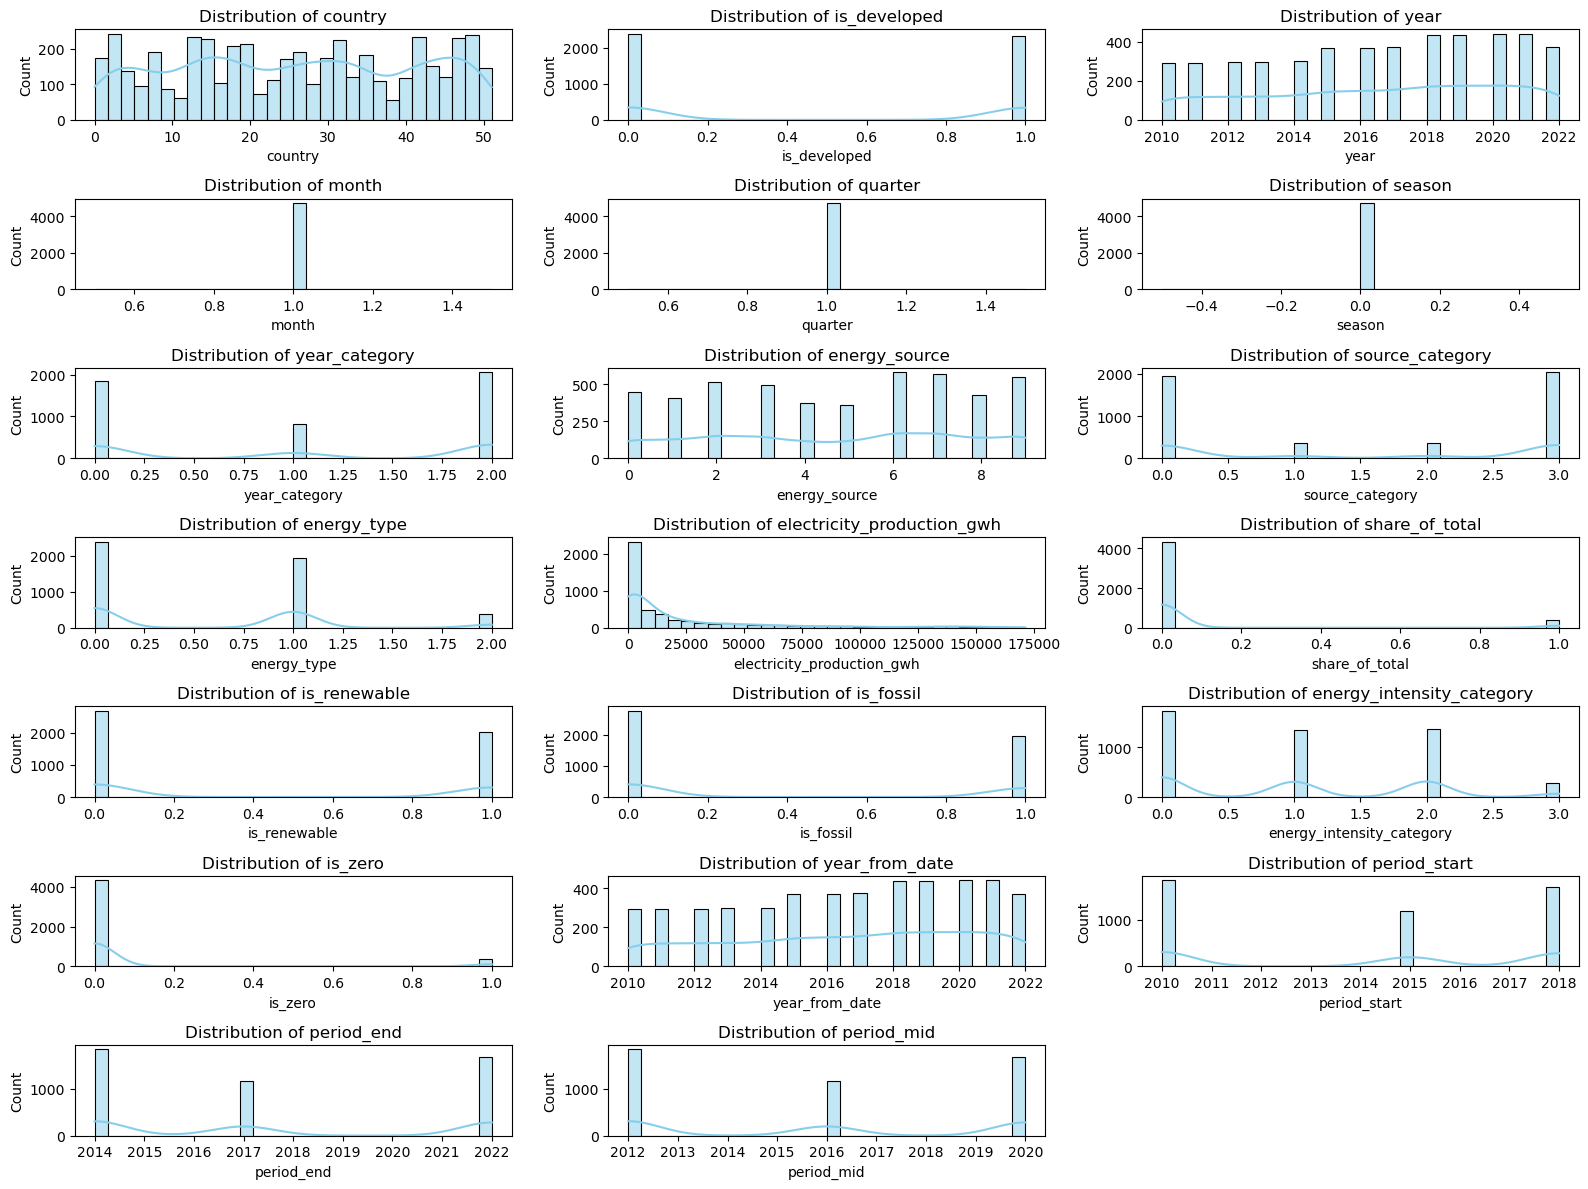

In [23]:
cols = data.select_dtypes(include=['int64','int32']).columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(cols):
    plt.subplot((len(cols) // 3) + 1, 3, i + 1)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Scatterplot

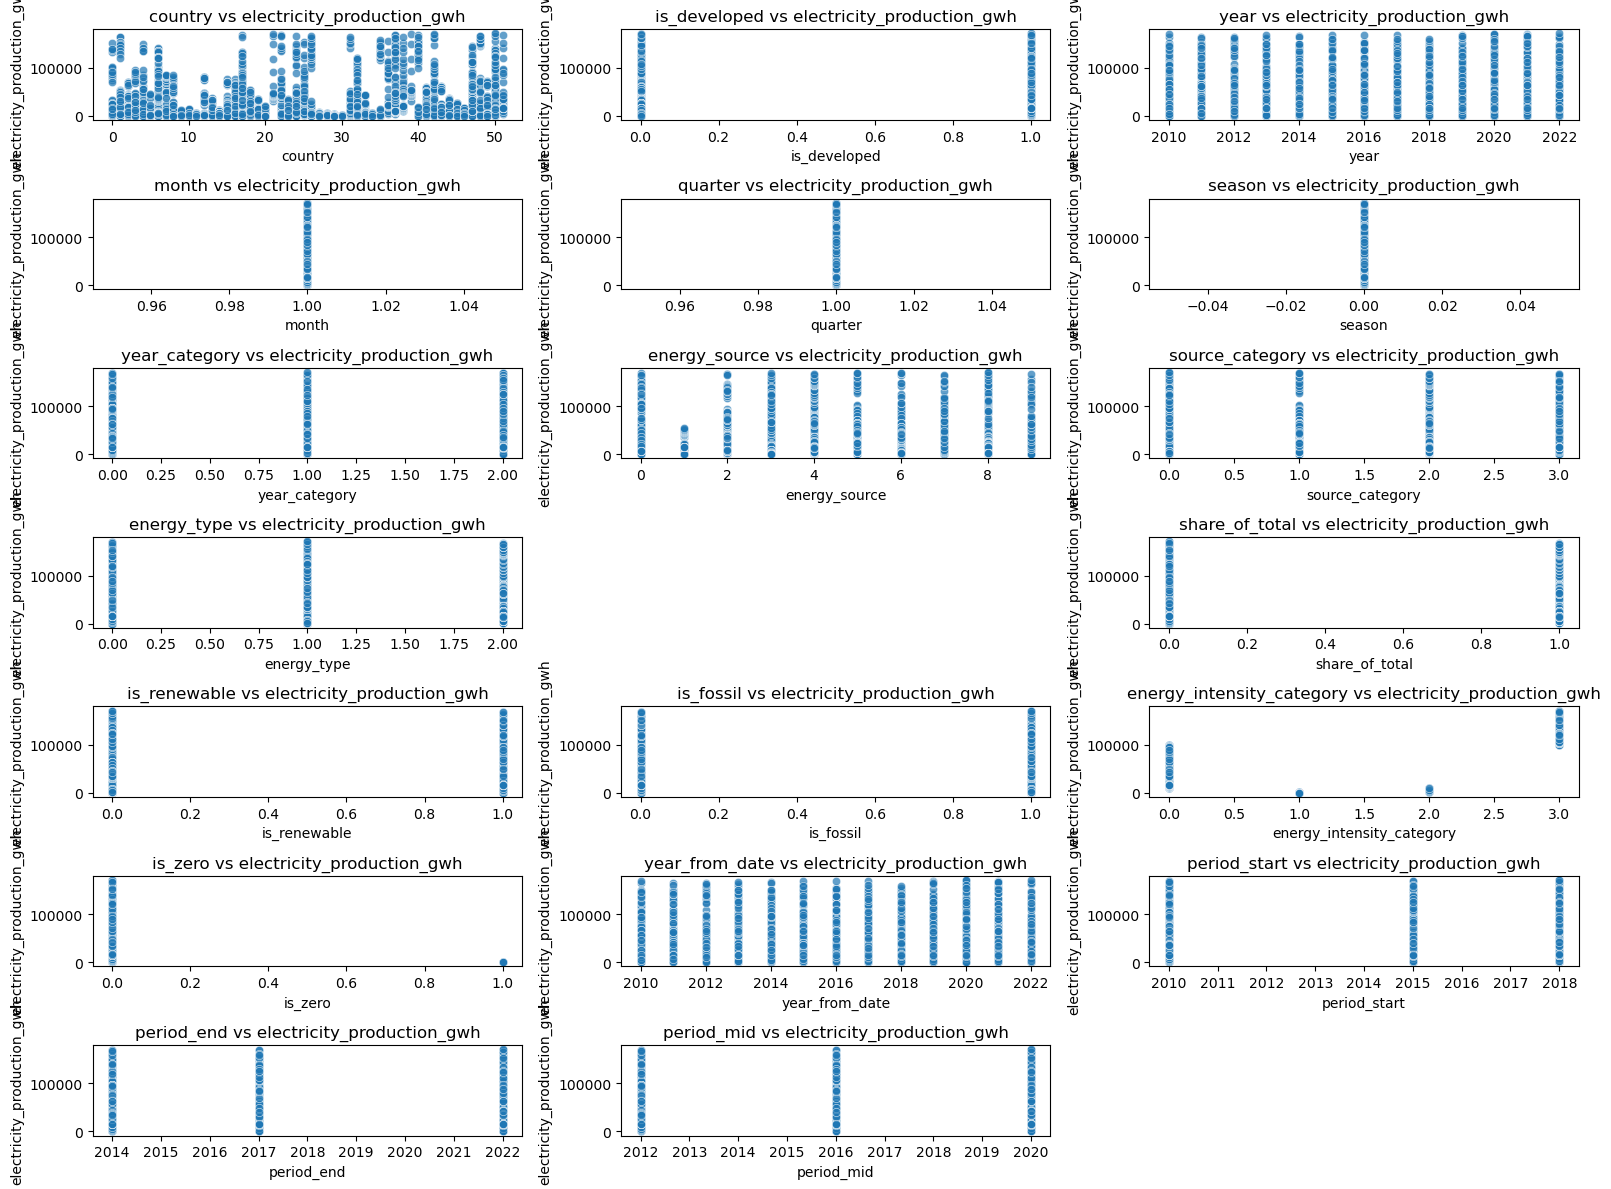

In [24]:
target = 'electricity_production_gwh'

plt.figure(figsize=(16, 12))
for i, col in enumerate(cols):
    if col != target:
        plt.subplot((len(cols) // 3) + 1, 3, i + 1)
        sns.scatterplot(x=data[col], y=data[target], alpha=0.7)
        plt.title(f"{col} vs {target}")
plt.tight_layout()
plt.show()

# Import Pipeline model

In [25]:
preprocessor = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

# Define models

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=537),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=537),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=537),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=537),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=537)
}

# Prediction

In [27]:
results = []

for name, model in models.items():
    pipeline = make_pipeline(preprocessor, model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "RMSE": rmse,
        'MAE': mae,
        "R2 Score": r2
    })
    
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df

,Model,RMSE,MAE,R2 Score
3,Random Forest,6497.814687,2823.348040,0.968028
6,Extra Trees,7025.105391,2947.910943,0.962628
9,XGBoost,7204.263377,3378.272378,0.960698
4,Gradient Boosting,12802.100924,7708.583132,0.875892
5,AdaBoost,15774.504364,9594.919365,0.811571
8,K-Nearest Neighbors,21911.158741,11294.912288,0.636447
2,Lasso Regression,33582.187640,24144.731424,0.146005
0,Linear Regression,33582.226789,24145.119477,0.146003
1,Ridge Regression,33582.528319,24144.467569,0.145988
7,Support Vector Regressor,40592.241465,22420.810292,-0.247737


# Define models & parameter grids for Regressor

In [28]:
models = {
    'LR': (LinearRegression(), {}),

    'Ridge': (Ridge(),
              {'alpha': [0.01, 0.1, 1.0, 10.0]}),

    'Lasso': (Lasso(max_iter=5000),
              {'alpha': [0.001, 0.01, 0.1, 1.0]}),

    'DT': (DecisionTreeRegressor(),
           {'max_depth': [3, 5, None],
            'min_samples_split': [2, 5, 10]}),

    'RF': (RandomForestRegressor(random_state=537),
           {'max_depth': [5, None],
            'n_estimators': [100, 200],
            'min_samples_split': [2, 5]}),

    'ExtraTrees': (ExtraTreesRegressor(random_state=537),
                   {'n_estimators': [100, 200],
                    'max_depth': [None, 10, 20],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]}),

    'AdaBoost': (AdaBoostRegressor(random_state=537),
                 {'n_estimators': [50, 100, 200],
                  'learning_rate': [0.01, 0.1, 1.0]}),

    'GB': (GradientBoostingRegressor(random_state=537),
           {'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]}),

    'XGB': (XGBRegressor(objective="reg:squarederror", random_state=537),
            {'max_depth': [3, 5],
             'n_estimators': [100, 200],
             'learning_rate': [0.05, 0.1]}),

    'SVR': (SVR(),
            {'kernel': ['linear', 'rbf'],
             'C': [0.1, 1, 10],
             'gamma': ['scale', 'auto']}),

    'KNN': (KNeighborsRegressor(),
            {'n_neighbors': [3, 5, 7],
             'weights': ['uniform', 'distance']})
}


# Run GridSearchCV for each regressor model

In [29]:
results = []
best_score = -float('inf')
best_model = None
best_name = None

for name, (model, param_grid) in models.items():  
    print(f"\n Running GridSearchCV for {name}...")
    grid = GridSearchCV(model, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

    print(f"{name} Best CV Score (R²): {grid.best_score_:.4f}")
    print(f"{name} Best Params: {grid.best_params_}")

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_name = name

# Output summary
results_df = pd.DataFrame(results)
print("\n Summary Results:")
print(results_df)

print(f"\n Best Model: {best_name}")
print(f" Best CV Score (R²): {best_score:.4f}")


 Running GridSearchCV for LR...
LR Best CV Score (R²): 0.1200
LR Best Params: {}

 Running GridSearchCV for Ridge...
Ridge Best CV Score (R²): 0.1202
Ridge Best Params: {'alpha': 10.0}

 Running GridSearchCV for Lasso...
Lasso Best CV Score (R²): 0.1200
Lasso Best Params: {'alpha': 1.0}

 Running GridSearchCV for DT...
DT Best CV Score (R²): 0.9328
DT Best Params: {'max_depth': None, 'min_samples_split': 5}

 Running GridSearchCV for RF...
RF Best CV Score (R²): 0.9515
RF Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

 Running GridSearchCV for ExtraTrees...
ExtraTrees Best CV Score (R²): 0.9362
ExtraTrees Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

 Running GridSearchCV for AdaBoost...
AdaBoost Best CV Score (R²): 0.8325
AdaBoost Best Params: {'learning_rate': 0.01, 'n_estimators': 50}

 Running GridSearchCV for GB...
GB Best CV Score (R²): 0.9419
GB Best Params: {'learning_rate': 0.1, 'max_depth':

# Scatter Plot: Predicted vs Actual

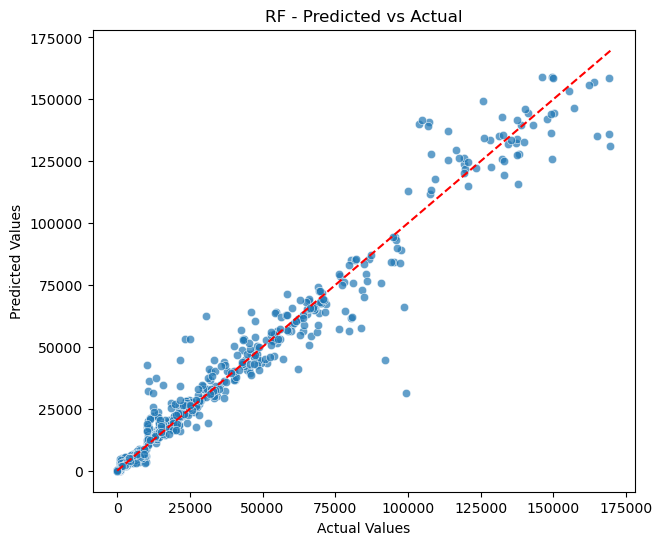

In [30]:
y_pred = best_model.predict(X_test)

# Scatter Plot: Predicted vs Actual
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"{best_name} - Predicted vs Actual")
plt.show()

# Residuals Distribution Histplot

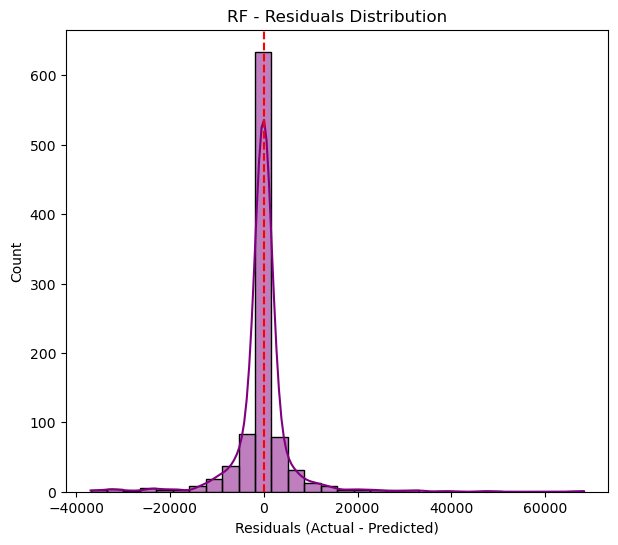

In [31]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals (Actual - Predicted)")
plt.title(f"{best_name} - Residuals Distribution")
plt.show()

# Feature Importances

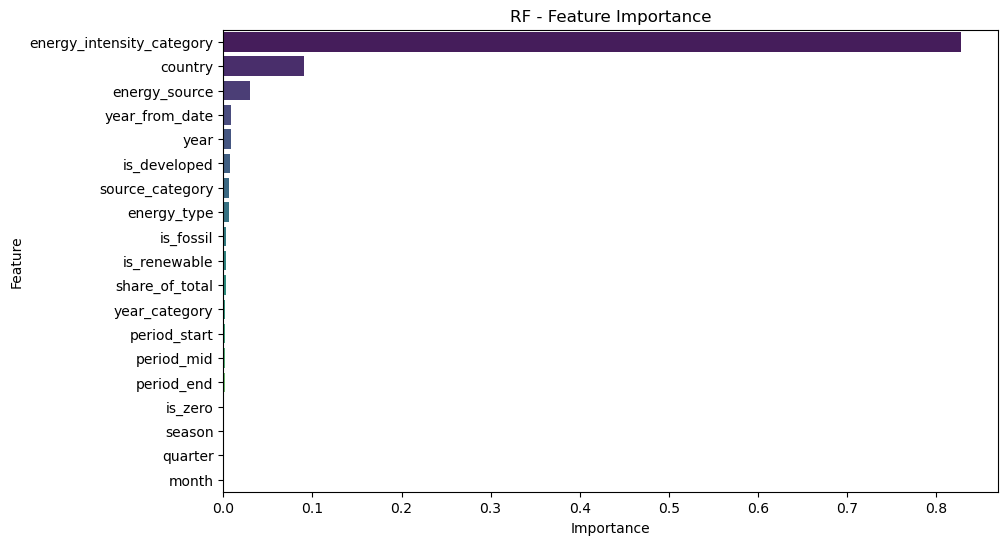

In [32]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
    plt.title(f"{best_name} - Feature Importance")
    plt.show()
else:
    print(f" Feature importance not available for {best_name}")

# Save the model

In [33]:
joblib.dump(best_model,'best model 14.global monthly electricity production final.joblib')

['best model 14.global monthly electricity production final.joblib']

In [34]:
feature_columns = X.columns.to_list()
joblib.dump(feature_columns,'features 14.global monthly electricity production final.joblib')

['features 14.global monthly electricity production final.joblib']